In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN

from sklearn.metrics import silhouette_score

from sklearn.decomposition import PCA

In [5]:
df = pd.read_csv("E:\ml assignment\diabetes_dataset_prediction\data\diabetes_cleaned.csv")

df.head()

<>:1: SyntaxWarning: invalid escape sequence '\m'
<>:1: SyntaxWarning: invalid escape sequence '\m'
C:\Users\Samya\AppData\Local\Temp\ipykernel_13224\2638332900.py:1: SyntaxWarning: invalid escape sequence '\m'
  df = pd.read_csv("E:\ml assignment\diabetes_dataset_prediction\data\diabetes_cleaned.csv")


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,0,1.700840,0,1,1,-0.317475,0.994563,0.043554,0
1,0,0.543372,0,0,0,0.007649,0.994563,-1.423096,0
2,1,-0.614096,0,0,1,0.007649,0.155970,0.483549,0
3,0,-0.257952,0,0,5,-0.583069,-0.496269,0.410216,0
4,1,1.522768,1,1,5,-1.088309,-0.682623,0.410216,0


In [6]:
X = df[[

    "age",
    "bmi",
    "HbA1c_level",
    "blood_glucose_level"

]]

In [7]:
X_scaled = X

In [8]:
# ELBOW METHOD 

wcss = []

for k in range(1,11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42
    )

    kmeans.fit(X_scaled)

    wcss.append(
        kmeans.inertia_
    )

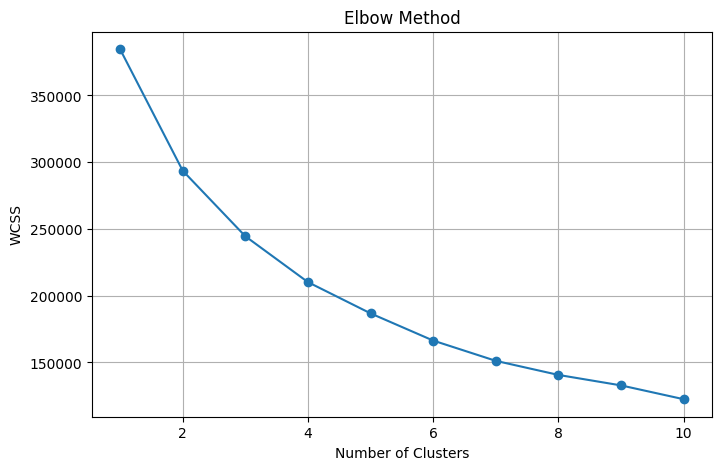

In [9]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker='o'
)

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.title("Elbow Method")

plt.grid(True)

plt.show()

In [8]:
# The elbow point represents the optimal number of clusters.

# The point where WCSS reduction starts slowing significantly is selected as best k.

In [9]:
silhouette_scores = []

for k in range(2,11):

    model = KMeans(
        n_clusters=k,
        random_state=42
    )

    labels = model.fit_predict(
        X_scaled
    )

    score = silhouette_score(
        X_scaled,
        labels
    )

    silhouette_scores.append(score)

    print(
        "k =",
        k,
        "Score =",
        score
    )

k = 2 Score = 0.21906556245392603
k = 3 Score = 0.21233738377137468
k = 4 Score = 0.224227064471783
k = 5 Score = 0.21787267884879222
k = 6 Score = 0.21813784729125335
k = 7 Score = 0.2280471499464362
k = 8 Score = 0.24121167968132595
k = 9 Score = 0.23333235361287613
k = 10 Score = 0.2411166792273181


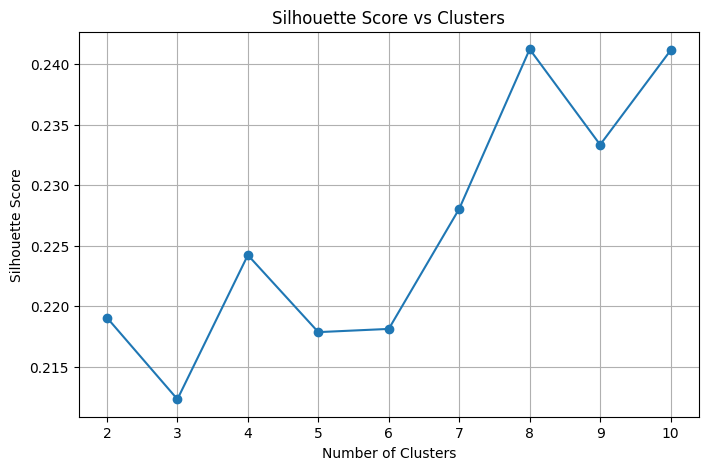

In [10]:
plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    silhouette_scores,
    marker='o'
)

plt.xlabel("Number of Clusters")

plt.ylabel("Silhouette Score")

plt.title("Silhouette Score vs Clusters")

plt.grid(True)

plt.show()

In [11]:
best_k = np.argmax(
    silhouette_scores
) + 2

print(
    "Best Number of Clusters:",
    best_k
)

Best Number of Clusters: 8


In [12]:
kmeans = KMeans(

    n_clusters=best_k,
    random_state=42

)

clusters = kmeans.fit_predict(
    X_scaled
)

In [13]:
df["Cluster"] = clusters

In [14]:
cluster_stats = df.groupby("Cluster")[[
    
    "age",
    "bmi",
    "HbA1c_level",
    "blood_glucose_level"

]].mean()

cluster_stats

,age,bmi,HbA1c_level,blood_glucose_level
Cluster,,,,
0,0.435342,0.123711,-1.097645,-1.219443
1,0.886722,0.020535,0.683703,-0.090239
2,-1.192100,-0.857034,-1.140712,-0.058400
3,0.829551,0.495720,1.068922,2.359996
4,-0.978624,-0.637165,0.539488,0.403509
5,-0.672864,-0.406573,0.467374,-1.174022
6,0.125530,1.955830,0.256248,-0.055205
7,0.520363,0.084678,-1.121027,0.380859


In [15]:
cluster_names = {

    0: "Low Glucose Healthy Patients",

    1: "Prediabetic Elderly Patients",

    2: "Young Healthy Patients",

    3: "High Risk Diabetic Patients",

    4: "Young Prediabetic Patients",

    5: "Low Glucose Moderate BMI Patients",

    6: "Obese Patients",

    7: "Moderate Risk Healthy Patients"

}

In [16]:
df["Cluster_Name"] = df[
    "Cluster"
].map(cluster_names)

In [17]:
df[[
    "Cluster",
    "Cluster_Name"
]].head()

,Cluster,Cluster_Name
0,1,Prediabetic Elderly Patients
1,5,Low Glucose Moderate BMI Patients
2,4,Young Prediabetic Patients
3,7,Moderate Risk Healthy Patients
4,7,Moderate Risk Healthy Patients


In [18]:
pca = PCA(n_components=2)

pca_features = pca.fit_transform(
    X_scaled
)

In [19]:
pca_df = pd.DataFrame({

    "PCA1": pca_features[:,0],

    "PCA2": pca_features[:,1],

    "Cluster": clusters

})

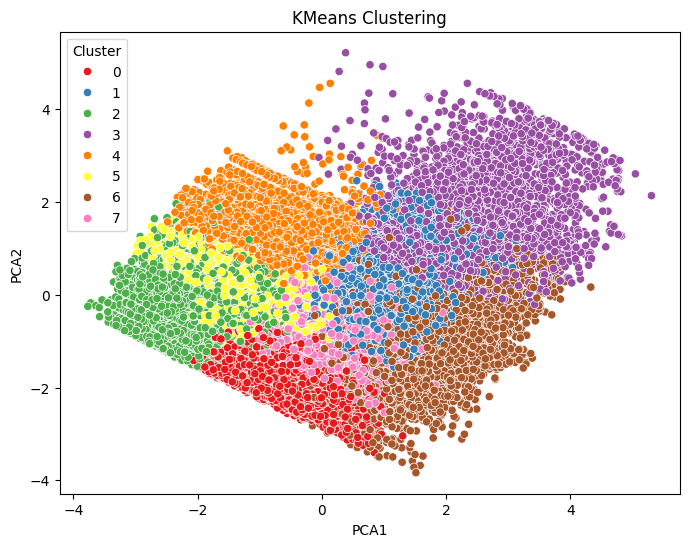

In [20]:
plt.figure(figsize=(8,6))

sns.scatterplot(

    x="PCA1",
    y="PCA2",

    hue="Cluster",

    data=pca_df,

    palette="Set1"

)

plt.title("KMeans Clustering")

plt.show()

In [21]:
kmeans_score = silhouette_score(
    X_scaled,
    clusters
)

print(
    "KMeans Silhouette Score:",
    kmeans_score
)

KMeans Silhouette Score: 0.24121167968132595


DBSCAN

In [22]:
eps_values = [

    0.3,
    0.5,
    0.7,
    0.9,
    1.1

]

dbscan_scores = []

In [23]:
for e in eps_values:

    dbscan = DBSCAN(

        eps=e,
        min_samples=5

    )

    labels = dbscan.fit_predict(
        X_scaled
    )

    unique_clusters = set(labels)

    if len(unique_clusters - {-1}) > 1:

        score = silhouette_score(
            X_scaled,
            labels
        )

        dbscan_scores.append(score)

        print(
            "eps =",
            e,
            "Score =",
            score
        )

    else:

        dbscan_scores.append(-1)

eps = 0.3 Score = -0.011174031203722642
eps = 0.5 Score = 0.14170296062629065
eps = 0.7 Score = 0.25707666387890377
eps = 0.9 Score = 0.25494385772370814


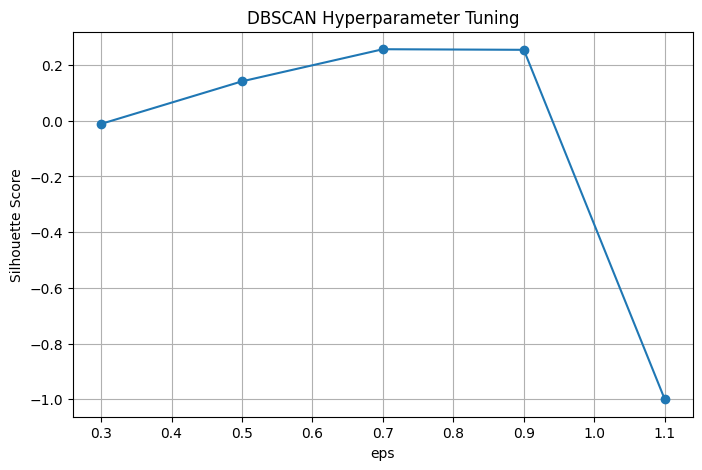

In [24]:
plt.figure(figsize=(8,5))

plt.plot(

    eps_values,
    dbscan_scores,
    marker='o'

)

plt.xlabel("eps")

plt.ylabel("Silhouette Score")

plt.title("DBSCAN Hyperparameter Tuning")

plt.grid(True)

plt.show()

In [25]:
best_eps = eps_values[
    np.argmax(dbscan_scores)
]

print(
    "Best eps:",
    best_eps
)

Best eps: 0.7


In [26]:
# FINAL DBSCAN MODEL

best_dbscan = DBSCAN(

    eps=best_eps,
    min_samples=5

)

dbscan_labels = best_dbscan.fit_predict(
    X_scaled
)

In [27]:
best_dbscan_score = max(
    dbscan_scores
)

print(
    "DBSCAN Silhouette Score:",
    best_dbscan_score
)

DBSCAN Silhouette Score: 0.25707666387890377


In [28]:
results = pd.DataFrame({

    "Model": [

        "KMeans",
        "DBSCAN"

    ],

    "Best Hyperparameter": [

        f"n_clusters = {best_k}",

        f"eps = {best_eps}"

    ],

    "Silhouette Score": [

        kmeans_score,

        best_dbscan_score

    ]

})

results

,Model,Best Hyperparameter,Silhouette Score
0,KMeans,n_clusters = 8,0.241212
1,DBSCAN,eps = 0.7,0.257077


In [29]:
best_model = results.loc[

    results[
        "Silhouette Score"
    ].idxmax()

]

best_model

Model                     DBSCAN
Best Hyperparameter    eps = 0.7
Silhouette Score        0.257077
Name: 1, dtype: object

In [30]:
pca_df["DBSCAN_Cluster"] = dbscan_labels

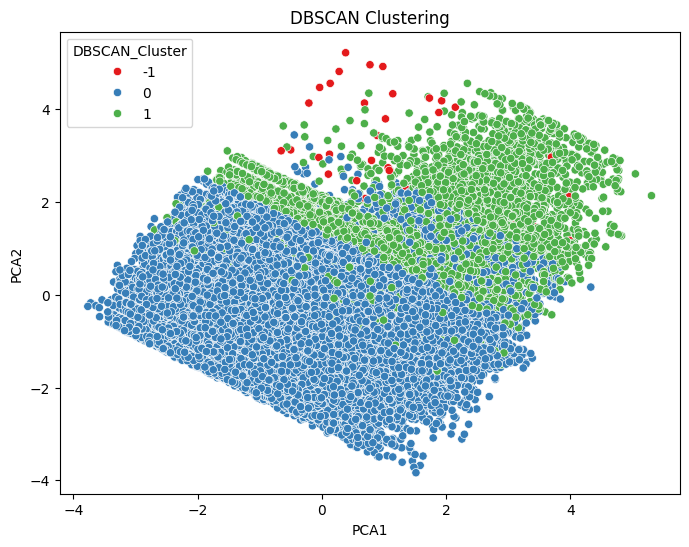

In [31]:
plt.figure(figsize=(8,6))

sns.scatterplot(

    x="PCA1",
    y="PCA2",

    hue="DBSCAN_Cluster",

    data=pca_df,

    palette="Set1"

)

plt.title("DBSCAN Clustering")

plt.show()

In [32]:
n_clusters = len(
    set(dbscan_labels)
) - (1 if -1 in dbscan_labels else 0)

print(
    "Number of Clusters:",
    n_clusters
)

Number of Clusters: 2


In [33]:
noise_points = list(
    dbscan_labels
).count(-1)

print(
    "Noise Points:",
    noise_points
)

Noise Points: 40


In [1]:
import joblib

In [3]:
joblib.dump(

    best_model,

    "E:\ml assignment\diabetes_dataset_prediction\models/best_dbscan_model.pkl"

)

<>:5: SyntaxWarning: invalid escape sequence '\m'
<>:5: SyntaxWarning: invalid escape sequence '\m'
C:\Users\Samya\AppData\Local\Temp\ipykernel_13224\775055775.py:5: SyntaxWarning: invalid escape sequence '\m'
  "E:\ml assignment\diabetes_dataset_prediction\models/best_dbscan_model.pkl"


NameError: name 'best_model' is not defined

In [ ]:
# The DBSCAN clustering graph visualizes patient groups after PCA dimensionality reduction.

# DBSCAN identified two major clusters along with several noise points.

# Blue and green regions represent dense patient groups with similar medical characteristics.

# Red points represent outliers that did not strongly belong to any cluster.

# Slight overlap between clusters indicates naturally overlapping medical conditions, which is common in healthcare datasets.